In [8]:
#Loading Data
import pandas as pd
df = pd.read_csv("titanic_passengers.csv")
df.head()
df.info()
df.describe()
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


#Summary
The Titanic dataset has passenger information that includes class, sex, age, ect. The aim of the project and research to predict passenger survival.

In [11]:
#Clean
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
# Cabin contains too many missing values for the analysis
df = df.drop('Cabin', axis=1)
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


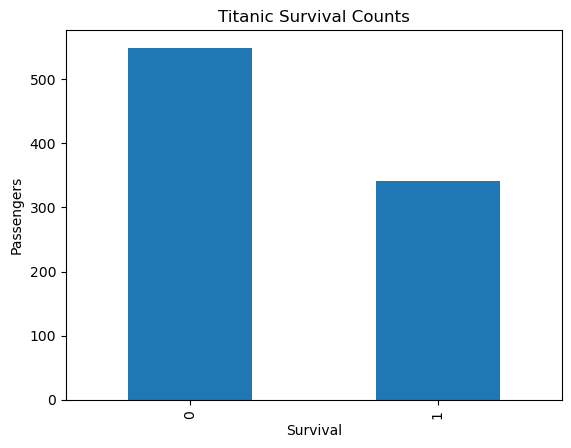

In [13]:
#Survival Distribution
import matplotlib.pyplot as plt
df['Survived'].value_counts().plot(kind='bar')
plt.title('Titanic Survival Counts')
plt.xlabel('Survival')
plt.ylabel('Passengers')
plt.show()

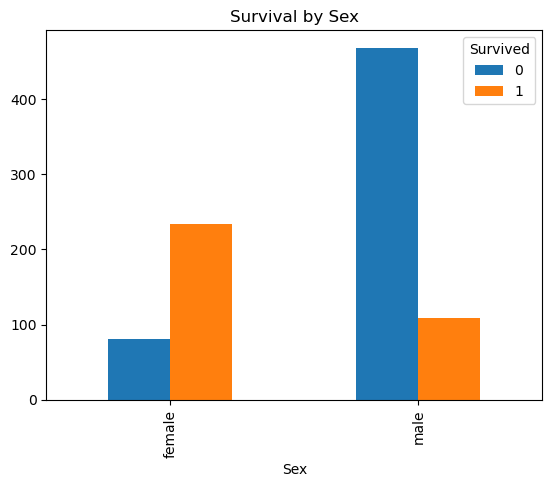

In [14]:
#Survival By Sex
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar')
plt.title('Survival by Sex')
plt.show()

In [17]:
#Adding Column
df['FamilySize'] = (df['SibSp'] + df['Parch'] + 1)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


The Family Size column was made in order to see whether traveling with a family affected your survival rate.

In [21]:
#Changing Features
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')
df.head()

x = df.drop('Survived', axis=1)
y = df['Survived']

In [22]:
#Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123321)

In [23]:
#Model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=123321)
model.fit(x_train, y_train)

RandomForestClassifier(random_state=123321)

In [24]:
#Validation
print("Training Score:", model.score(x_train, y_train))
print ("Testing Score:", model.score(x_test, y_test))

Training Score: 0.9831460674157303
Testing Score: 0.8100558659217877


In [25]:
#Classification Report
from sklearn.metrics import classification_report
predictions = model.predict(x_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.81      0.86      0.84       102
           1       0.80      0.74      0.77        77

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [26]:
#Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
print(cm)

[[88 14]
 [20 57]]
